# Abacus small box: one-at-a-time LRG parameter variations

Generate a fiducial single-tracer LRG catalogue at **z = 0.5**, then change one scalar parameter at a time. We compare satellite and central velocity bias, concentration/environment/shear assembly bias (central and satellite coefficients separately), and satellite-count dispersion `nu`.

All clustering panels use **`HOD.plot_stats`**, with the fiducial mock passed as **data**. The lower panels show `model / fiducial - 1` for $w_p$, $\xi_0$, and $\xi_2$. These are fractional differences, without measurement-error or significance estimates. Ratios can become large when the fiducial quadrupole crosses zero; exactly zero reference bins are omitted by the plotter.

Dependencies are the standard HODDIES environment: NumPy, SciPy, Matplotlib, Numba, abacusutils, mpytools, Corrfunc/pycorr and cosmoprimo with CLASS. Run cells in order, with a Python kernel using that environment. The first run reads particle files and compiles Numba kernels; subsequent runs reuse the cached environment fields. The HOD values below are illustrative, rather than a fit to observed LRGs.

In [1]:
from pathlib import Path
from copy import deepcopy
import os
import sys
import tempfile

repo_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
                  if (p / "HODDIES" / "hod.py").is_file()), None)
if repo_root is None:
    raise RuntimeError("Start the notebook from the HODDIES repository or Notebooks directory.")
sys.path.insert(0, str(repo_root))
os.environ.setdefault("NUMBA_CACHE_DIR", str(Path(tempfile.gettempdir()) / "hoddies-tutorial-numba"))

import numpy as np
import numba
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from HODDIES import HOD
from HODDIES.sim_loader import AbacusSummitSim
from HODDIES.environment_func import tsc_parallel, calc_shear_from_dsmo
from HODDIES.plot_utils import get_STATS, register_stat

NTHREADS = 4
FIX_SEED = 42
N_VARIATIONS = 50  # np.linspace default: lower this for a quicker preview
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

## Load the local small box

The default uses NFW satellite positions and Gaussian satellite velocities (`use_particles=False`, `vel_sat="rd_normal"`). Particle subsamples are loaded separately only to measure the environment and shear. Thus `f_sigv` varies the Gaussian satellite velocity dispersion in this notebook. Setting `USE_PARTICLES=True` instead uses halo particles, with the existing prescription `v_sat = v_h + f_sigv * (v_part - v_h)`; the baseline `f_sigv=1` leaves their velocities unbiased.

In [2]:
ABACUS_ROOT = Path("/home/antoine/Bureau/Transfert/postdoc/Abacus_sims")
SIM_NAME = "AbacusSummit_small_c000_ph3000"
Z_SIM = 0.5
MASS_CUT = 11.2
USE_PARTICLES = False

snapshot = ABACUS_ROOT / "small" / SIM_NAME / "halos" / f"z{Z_SIM:.3f}"
if not (snapshot / "halo_info").is_dir():
    raise FileNotFoundError(f"Missing Abacus snapshot: {snapshot}")
simulation = AbacusSummitSim(
    path_to_sim=str(ABACUS_ROOT), sim_name=SIM_NAME, z_simu=Z_SIM,
    mass_cut=MASS_CUT, load_particles=USE_PARTICLES, nthreads=NTHREADS,
)
volume = float(simulation.boxsize) ** 3
print(f"Loaded {len(simulation.hcat):,} halos; L = {simulation.boxsize:g} Mpc/h")

/home/antoine/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
Loaded 2,903,574 halos; L = 500 Mpc/h


## Prepare genuine concentration, environment and shear ranks

Concentration `c` is already supplied by the halo loader. For environment and shear, retain 10% of the available **A subsample**, combining both halo and field particles to sample the matter distribution. This is not 10% of all simulation particles. Deposit particles with the existing TSC utility and apply a periodic Gaussian smoothing of radius **5 Mpc/h** on a **128³** mesh. Compute shear using the existing tidal-shear utility (`R=None` avoids a second smoothing). The mesh size, smoothing and sampling fraction are tutorial settings: increase resolution/sampling and check convergence for scientific use.

The two meshes are cached under the system temporary directory (`hoddies-tutorial-fields`), with simulation, snapshot, mesh, smoothing, sampling fraction and seed encoded in the cache name. We explicitly attach them to the simulation, then call the existing halo-sampling and mass-bin-ranking methods. Each property is ranked from −0.5 to +0.5 in 50 halo-mass bins before constructing the HOD object.

In [3]:
N_ENV_MESH = 128
R_ENV = 5.0                 # Mpc/h, Gaussian smoothing radius
PARTICLE_FRACTION = 0.1     # Fraction of Abacus subsample A
RANK_BINS = 50
cache_dir = Path(tempfile.gettempdir()) / "hoddies-tutorial-fields"
cache_dir.mkdir(parents=True, exist_ok=True)
mesh_cache = cache_dir / (
    f"{SIM_NAME}_z{Z_SIM:.3f}_n{N_ENV_MESH}_R{R_ENV:g}"
    f"_A-halo-field_f{PARTICLE_FRACTION:g}_seed{FIX_SEED}_periodic_gaussian_v1.npz"
)
cell_size = float(simulation.boxsize) / N_ENV_MESH
if mesh_cache.is_file():
    with np.load(mesh_cache) as saved:
        simulation.density_mesh = saved["density"]
        simulation.shear_mesh = saved["shear"]
    print("Loaded cached environment/shear:", mesh_cache.name)
else:
    particles = simulation.load_particle_field(
        subsample="A", fraction=PARTICLE_FRACTION, seed=FIX_SEED,
        load=("pos",), populations=("halo", "field"),
    )
    positions = np.asarray(particles["pos"], dtype=np.float32)
    print(f"Retained {len(positions):,} matter particles")
    counts = tsc_parallel(positions, N_ENV_MESH, simulation.boxsize, nthread=NTHREADS)
    density_contrast = counts / counts.mean() - 1.0
    simulation.density_mesh = gaussian_filter(
        density_contrast, sigma=R_ENV / cell_size, mode="wrap",
    ).astype(np.float32)
    simulation.shear_mesh = calc_shear_from_dsmo(
        simulation.density_mesh.copy(), simulation.boxsize,
        cell_size=cell_size, R=None, workers=NTHREADS,
    )
    np.savez_compressed(mesh_cache, density=simulation.density_mesh, shear=simulation.shear_mesh)
    del particles, positions, counts, density_contrast
    print("Saved environment/shear:", mesh_cache.name)

simulation.get_env_col()
missing = simulation.set_assembly_bias_values(["c", "shear", "env"], bins=RANK_BINS)
if missing:
    raise RuntimeError(f"Missing assembly-bias properties: {missing}")
for proxy in ("c", "shear", "env"):
    ranks = np.asarray(simulation.hcat[f"ab_{proxy}"])
    assert np.all(np.isfinite(ranks)) and np.ptp(ranks) > 0
    print(f"ab_{proxy}: [{ranks.min():.3f}, {ranks.max():.3f}]")

Loaded cached environment/shear: AbacusSummit_small_c000_ph3000_z0.500_n128_R5_A-halo-field_f0.1_seed42_periodic_gaussian_v1.npz
ab_c: [-0.500, 0.500]
ab_shear: [-0.500, 0.500]
ab_env: [-0.500, 0.500]


## Fiducial LRG HOD and redshift-space statistics

The fiducial has `f_sigv=1`, `f_vcen=0`, no assembly bias, and Poisson satellites (`nu=1`). Each assembly-bias entry is `[central coefficient, satellite coefficient]`. All runs keep the same halo catalogue, cosmology, HOD parameters and seed; `density=None` prevents automatic number-density renormalization from changing the other parameters. Counts may nevertheless change for occupation variations. A shared seed reduces realization differences, but cannot remove them when occupation draws change.

The current central prescription is **$v_{c,j}=v_{h,j}+f_{\rm vcen}V_{\rm rms}$ for each Cartesian component** (a deterministic offset, rather than an additional Gaussian draw). Redshift-space clustering uses the z line of sight. $w_p$ integrates to $\pi_{\max}=40\,h^{-1}\mathrm{Mpc}$, so a velocity change can affect this finite projection too.

In [4]:
LRG_FIDUCIAL = dict(
    HOD_model="SHOD", Ac=0.6, log_Mcent=12.8, sigma_M=0.4,
    satellites=True, sat_HOD_model="Nsat_pow_law",
    As=0.6, M_0=12.8, M_1=13.8, alpha=1.0,
    density=None, nu=1.0, link_sat_to_central=False, conformity_bias=False,
    vel_sat="rd_normal", f_sigv=1.0, f_vcen=0.0, vsmear=0.0,
    assembly_bias={"c": [0.0, 0.0], "shear": [0.0, 0.0], "env": [0.0, 0.0]},
)
CLUSTERING_SETTINGS = {
    "rsd": True, "los": "z",
    "xi_rppi": {"rp_min": 0.3, "rp_max": 25.0, "n_rp_bins": 18, "pimax": 40},
    "xi_smu": {"smin": 0.3, "smax": 40.0, "n_s_bins": 20,
               "n_mu_bins": 81, "multipole_index": [0, 2]},
}
if "Vrms" not in simulation.hcat.columns():
    raise RuntimeError("Vrms is needed to demonstrate central velocity bias.")
# Fix the thread count independently of whether the environment cache was used.
numba.set_num_threads(NTHREADS)
hod = HOD(
    simulation, tracers=["LRG"], LRG=deepcopy(LRG_FIDUCIAL),
    clustering_settings=deepcopy(CLUSTERING_SETTINGS),
    use_particles=USE_PARTICLES, use_assembly_bias=True,
    nthreads=NTHREADS, seed=FIX_SEED,
)
# Preserve all defaults merged by HOD (including satellite-placement settings).
LRG_FIDUCIAL = deepcopy(hod.args["LRG"])
fiducial = hod.make_mock_cat(fix_seed=FIX_SEED, verbose=False)
fiducial_stats = hod.compute_stats(fiducial, stat=["wp", "xi_ells"], tracers=["LRG"])
rp, wp_fid = fiducial_stats["wp"]["LRG_LRG"]
s, xi_fid = fiducial_stats["xi_ells"]["LRG_LRG"]
print(f"Fiducial: {len(fiducial):,} LRGs; n = {len(fiducial)/volume:.4e} h^3/Mpc^3; "
      f"satellite fraction = {np.mean(fiducial['Central'] == 0):.3f}")

setup_logger True
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Fiducial: 61,712 LRGs; n = 4.9370e-04 h^3/Mpc^3; satellite fraction = 0.136


## Plotting helper: fiducial data and fractional residuals

`plot_stats` normally uses residuals normalized by data errors. Its existing statistic registry also supports `residual="ratio"`. Here we register three plotting aliases with the same `wp` and `xi_ells` estimators, scales and labels, but ratio residuals. This preserves the standard plotting definitions for other notebooks and avoids inventing a covariance. The data arrays below contain the raw fiducial statistics; `plot_stats` applies the presentation scale itself.

Each experiment starts from a deep copy of the complete fiducial configuration. The helper checks that exactly one scalar changed, restores the fiducial settings afterwards, and records galaxy counts and satellite fractions. Only the current varied catalogue is retained in memory.

Each sweep uses **50 evenly spaced values** by default (`np.linspace`). The satellite velocity grid covers **0.5 to 1.5**, the central velocity grid **0 to 0.5**, each assembly coefficient **−1 to +1**, and `nu` **0.7 to 2**. Change `N_VARIATIONS` to adjust the resolution and runtime. Curves are colored by their parameter value, with a continuous colorbar; the black curve and gray points remain the fiducial reference. The model is evaluated at discrete grid points, without interpolation between catalogues.


In [5]:
PARAMETER_GRIDS = {
    "f_sigv": np.linspace(0.5, 1.5, N_VARIATIONS),
    "f_vcen": np.linspace(0.0, 0.5, N_VARIATIONS),
    "assembly_bias": np.linspace(-1.0, 1.0, N_VARIATIONS),
    "nu": np.linspace(0.7, 2.0, N_VARIATIONS),
}

PLOT_STATS = []
for name in ("wp", "xi0", "xi2"):
    alias = f"{name}_fiducial_ratio"
    register_stat(alias, **{**vars(get_STATS()[name]), "residual": "ratio", "residual_ylim": None})
    PLOT_STATS.append(alias)
FIDUCIAL_DATA = {
    PLOT_STATS[0]: {"LRG": (rp, wp_fid)},
    PLOT_STATS[1]: {"LRG": (s, xi_fid[0])},
    PLOT_STATS[2]: {"LRG": (s, xi_fid[1])},
}
run_summary = [{"parameter": "fiducial", "value": "—", "N": len(fiducial),
                "f_sat": float(np.mean(fiducial["Central"] == 0))}]

def scalar_parameters(params):
    flat = {key: value for key, value in params.items() if key != "assembly_bias"}
    for proxy, values in params["assembly_bias"].items():
        for index, value in enumerate(values):
            flat[f"assembly_bias.{proxy}.{index}"] = value
    return flat

def plot_variation(parameter, values, title, proxy=None, component=None):
    """Sweep one scalar; overlay wp, xi0 and xi2 with fiducial ratio residuals."""
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or len(values) < 2 or not np.all(np.isfinite(values)) or np.ptp(values) == 0:
        raise ValueError("Provide a finite one-dimensional grid with at least two distinct values.")
    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=values.min(), vmax=values.max())
    hod.args["LRG"] = deepcopy(LRG_FIDUCIAL)
    fig = hod.plot_stats(
        fiducial, stats=PLOT_STATS, tracers=["LRG"], data=FIDUCIAL_DATA,
        residuals=True, show=False, color="black", data_color="0.35",
        label="Fiducial", figsize=(14, 6), fontsize=10, lw=2.2, zorder=4,
    )
    try:
        for value in values:
            color = cmap(norm(value))
            params = deepcopy(LRG_FIDUCIAL)
            key = parameter
            if proxy is None:
                params[parameter] = float(value)
            else:
                params["assembly_bias"][proxy][component] = float(value)
                key = f"assembly_bias.{proxy}.{component}"
            original, varied = scalar_parameters(LRG_FIDUCIAL), scalar_parameters(params)
            changed = [k for k in original if original[k] != varied[k]]
            # The grid may include the fiducial value, where no scalar changes.
            assert changed == ([key] if original[key] != varied[key] else []), (
                f"Expected only {key} to change; got {changed}"
            )
            hod.args["LRG"] = params
            mock = hod.make_mock_cat(fix_seed=FIX_SEED, verbose=False) if changed else fiducial
            hod.plot_stats(
                mock, stats=PLOT_STATS, tracers=["LRG"], fig=fig,
                residuals=True, show=False, color=color,
                label="_nolegend_", fontsize=10, lw=0.9, alpha=0.75,
            )
            run_summary.append({"parameter": key, "value": value, "N": len(mock),
                                "f_sat": float(np.mean(mock["Central"] == 0))})
            del mock
    finally:
        hod.args["LRG"] = deepcopy(LRG_FIDUCIAL)
    # A colorbar replaces a long legend with one entry for every curve.
    # plot_stats uses a GridSpec with explicit bounds; move every panel
    # together to reserve space while keeping main/residual axes aligned.
    panels = [ax for main, resid in fig._plot_stats_axes
              for ax in (*main, *resid) if ax is not None]
    left = min(ax.get_position().x0 for ax in panels)
    right = max(ax.get_position().x1 for ax in panels)
    shrink = (0.86 - left) / (right - left)
    for ax in panels:
        pos = ax.get_position()
        ax.set_position([left + (pos.x0 - left) * shrink,
                         pos.y0, pos.width * shrink, pos.height])
    colorbar_axis = fig.add_axes([0.91, 0.16, 0.015, 0.68])
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(values)
    fig.colorbar(mappable, cax=colorbar_axis, label=parameter)
    fig.suptitle(title, y=1.02)
    plt.show()
    return fig

## Satellite velocity bias

Change the satellite velocity dispersion around the default `f_sigv=1`.

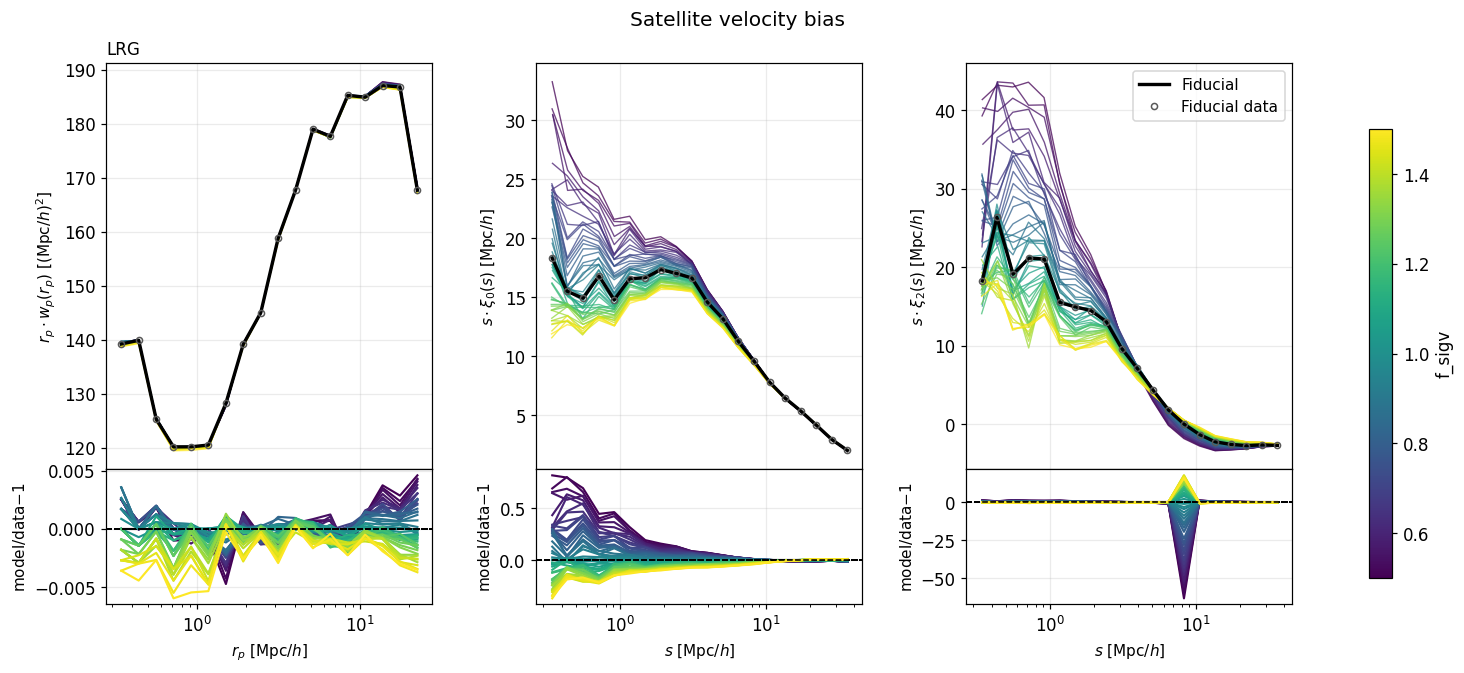

In [6]:
fig = plot_variation('f_sigv', PARAMETER_GRIDS["f_sigv"], 'Satellite velocity bias')
plt.close(fig)

## Central velocity bias

Change the central velocity offset from the default `f_vcen=0`.

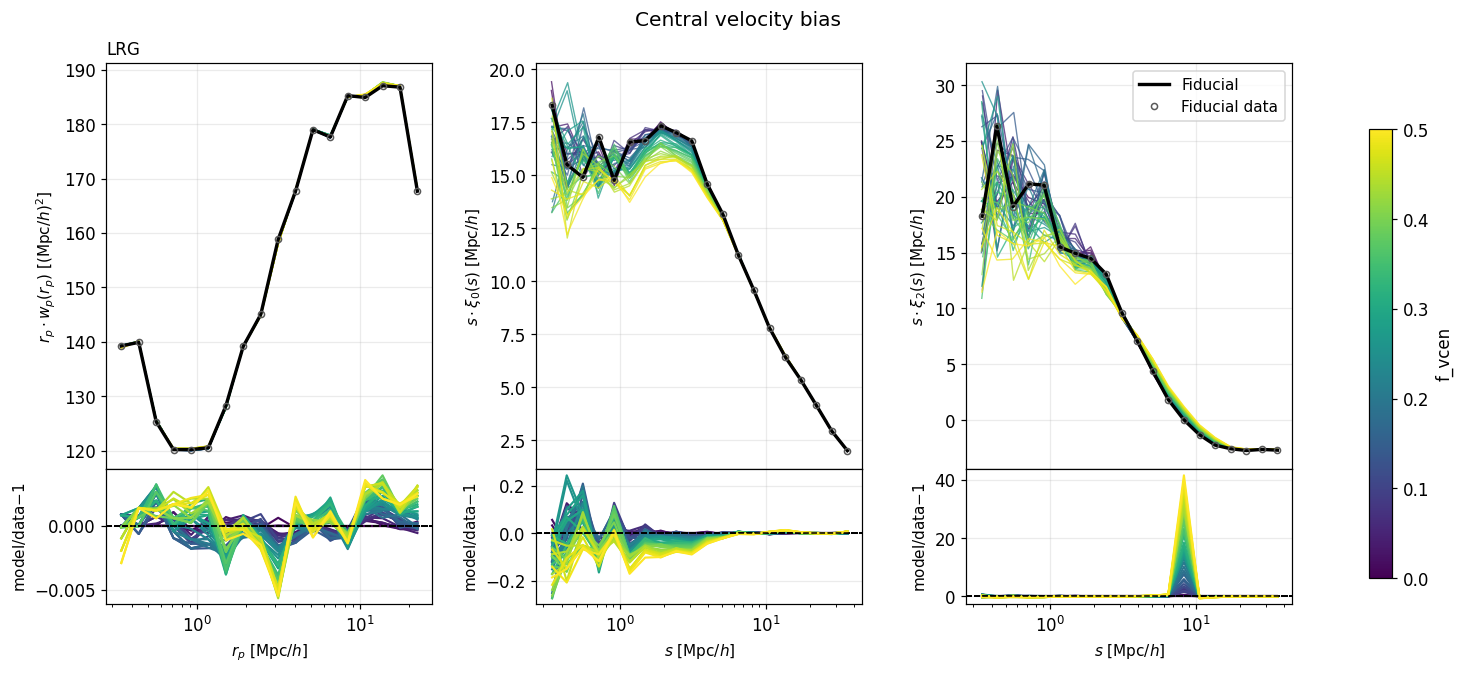

In [7]:
fig = plot_variation('f_vcen', PARAMETER_GRIDS["f_vcen"], 'Central velocity bias')
plt.close(fig)

## Concentration: central assembly bias

Vary only the central coefficient of `assembly_bias["c"]`; its other coefficient and every other parameter remain fiducial.

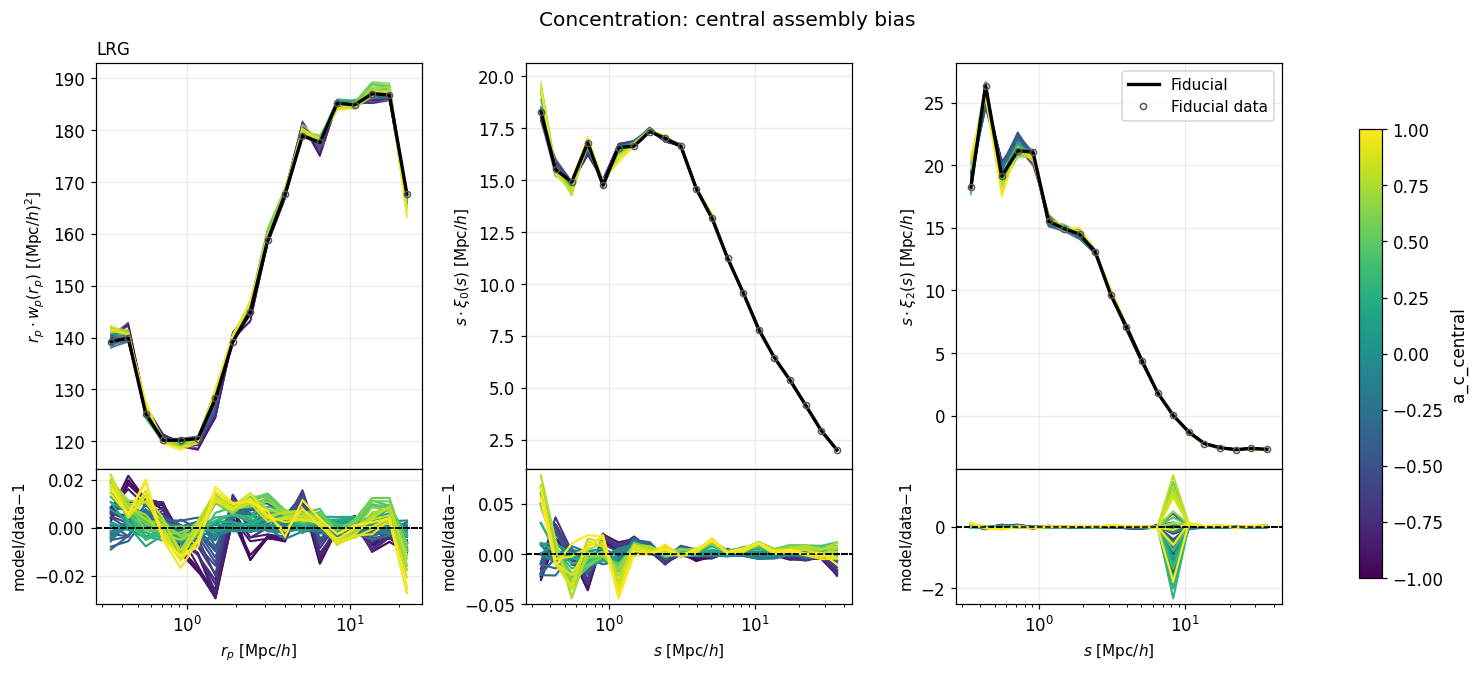

In [8]:
fig = plot_variation('a_c_central', PARAMETER_GRIDS["assembly_bias"], 'Concentration: central assembly bias', proxy='c', component=0)
plt.close(fig)

## Concentration: satellite assembly bias

Vary only the satellite coefficient of `assembly_bias["c"]`; its other coefficient and every other parameter remain fiducial.

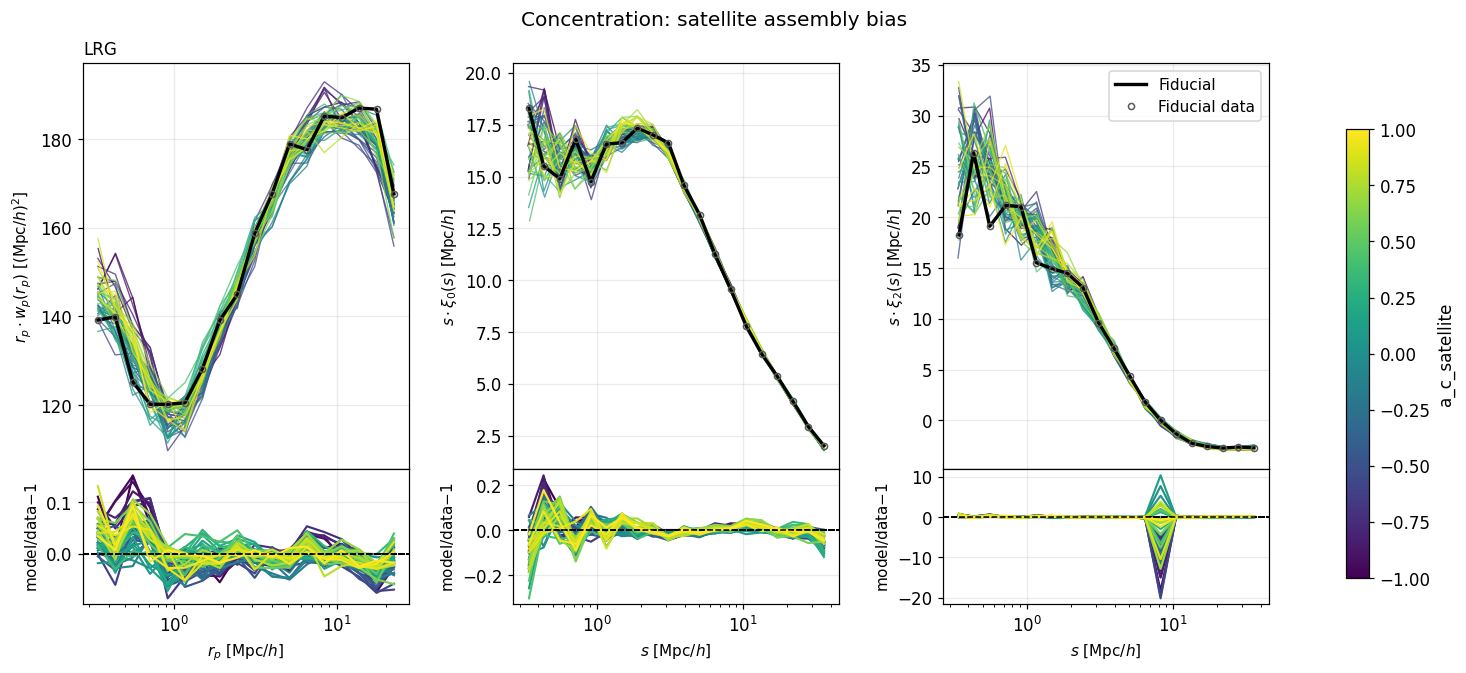

In [9]:
fig = plot_variation('a_c_satellite', PARAMETER_GRIDS["assembly_bias"], 'Concentration: satellite assembly bias', proxy='c', component=1)
plt.close(fig)

## Shear: central assembly bias

Vary only the central coefficient of `assembly_bias["shear"]`; its other coefficient and every other parameter remain fiducial.

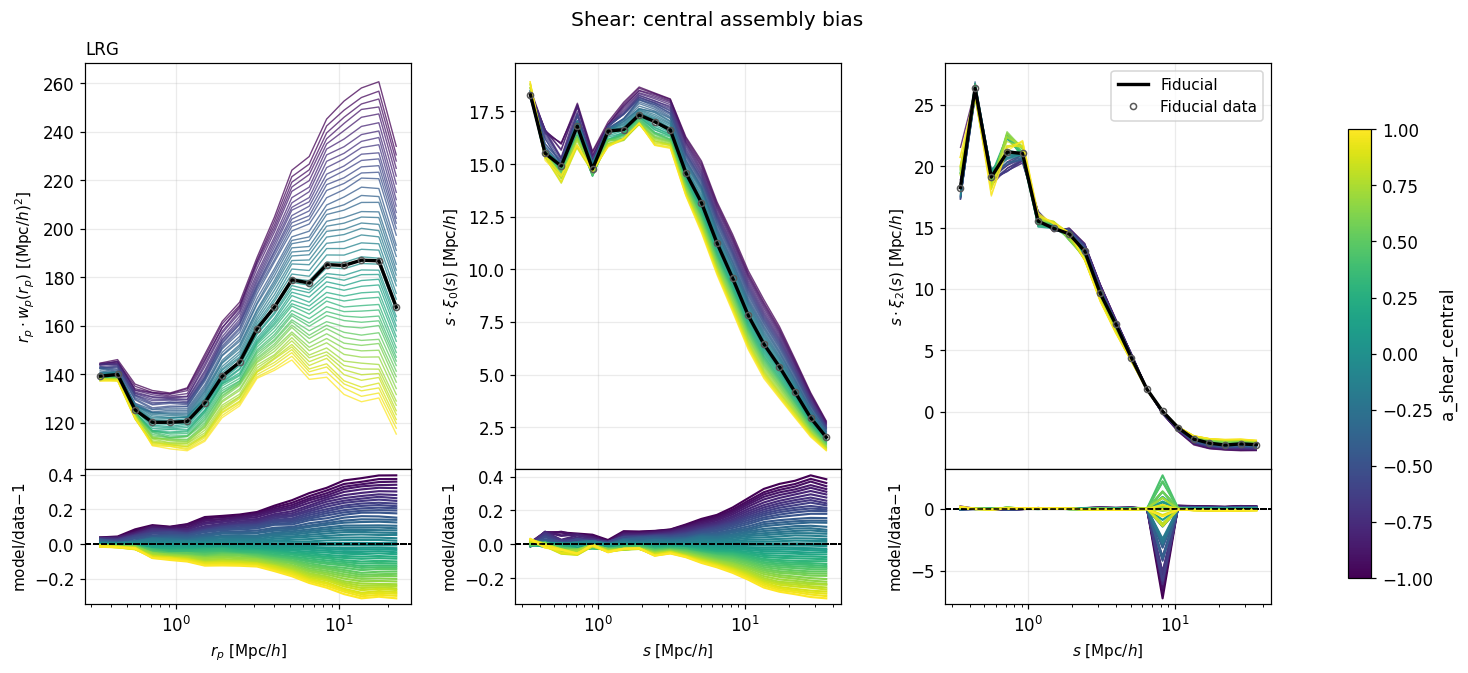

In [10]:
fig = plot_variation('a_shear_central', PARAMETER_GRIDS["assembly_bias"], 'Shear: central assembly bias', proxy='shear', component=0)
plt.close(fig)

## Shear: satellite assembly bias

Vary only the satellite coefficient of `assembly_bias["shear"]`; its other coefficient and every other parameter remain fiducial.

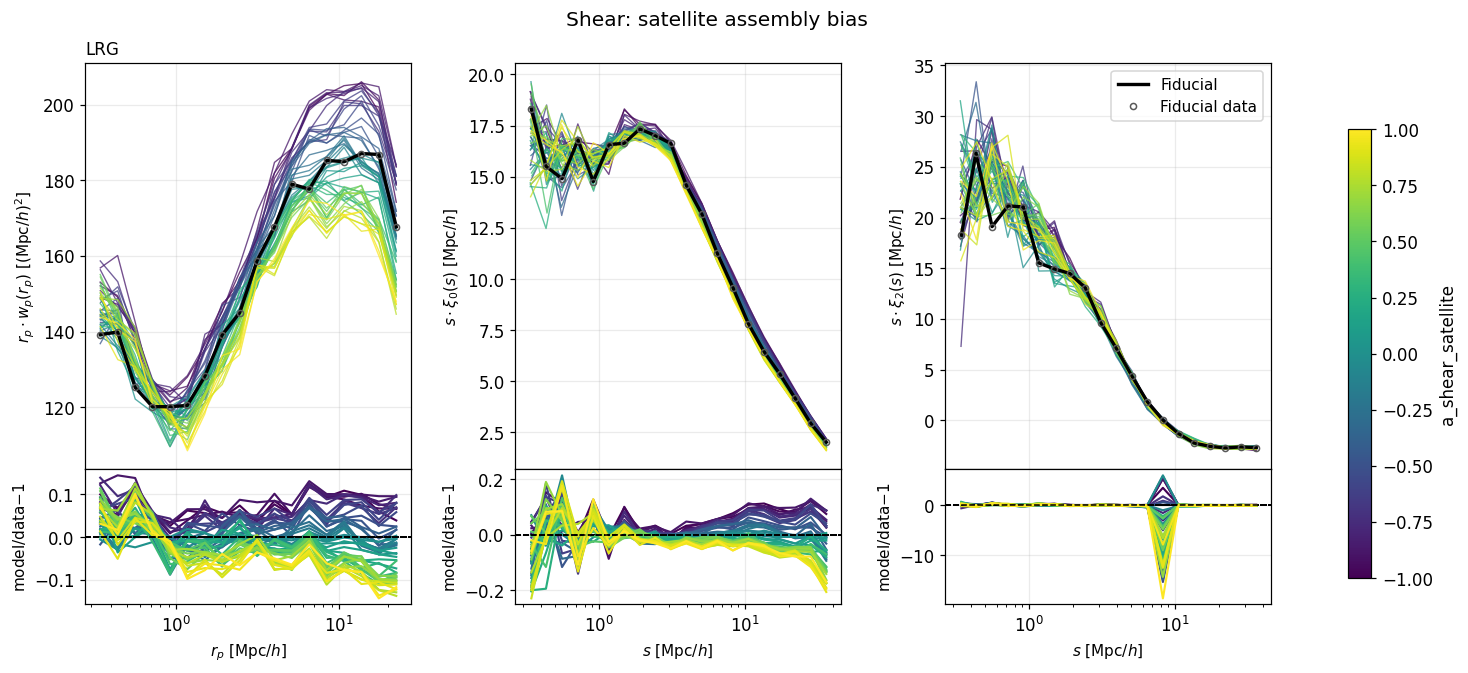

In [11]:
fig = plot_variation('a_shear_satellite', PARAMETER_GRIDS["assembly_bias"], 'Shear: satellite assembly bias', proxy='shear', component=1)
plt.close(fig)

## Environment: central assembly bias

Vary only the central coefficient of `assembly_bias["env"]`; its other coefficient and every other parameter remain fiducial.

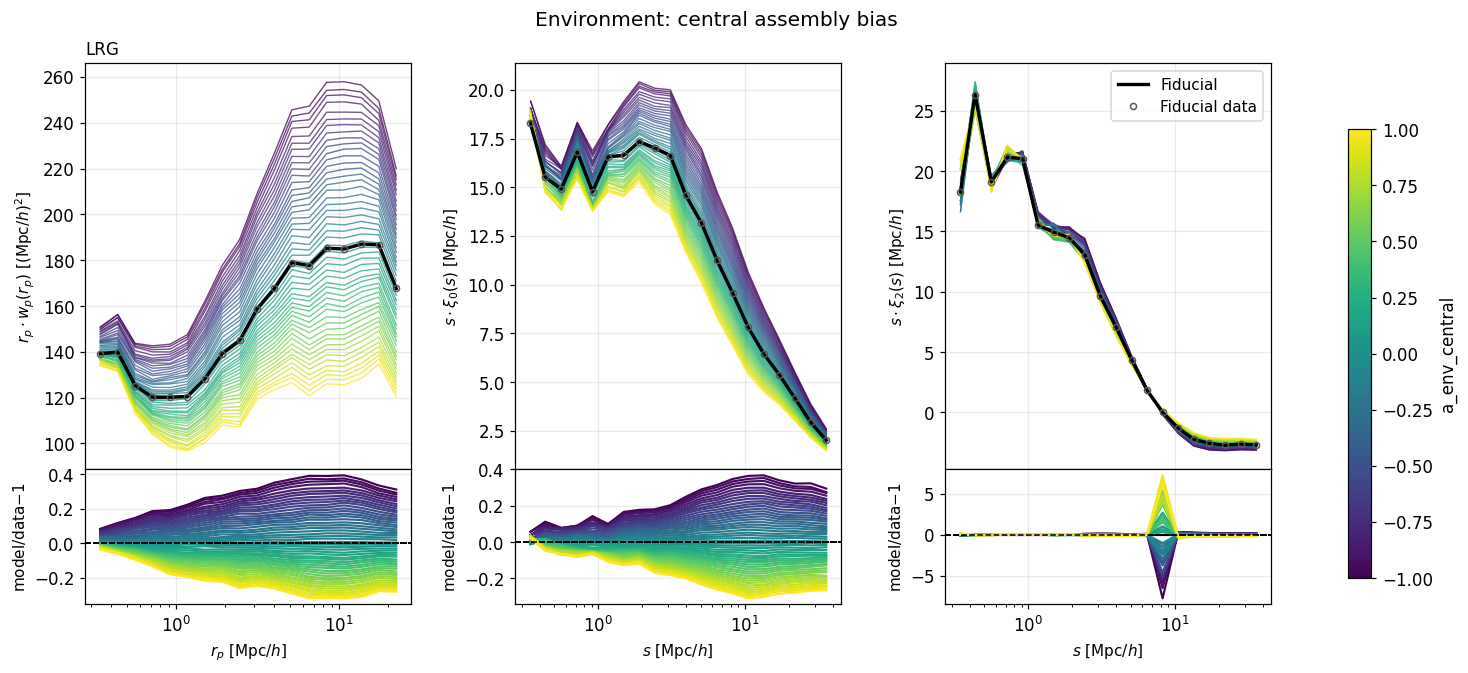

In [12]:
fig = plot_variation('a_env_central', PARAMETER_GRIDS["assembly_bias"], 'Environment: central assembly bias', proxy='env', component=0)
plt.close(fig)

## Environment: satellite assembly bias

Vary only the satellite coefficient of `assembly_bias["env"]`; its other coefficient and every other parameter remain fiducial.

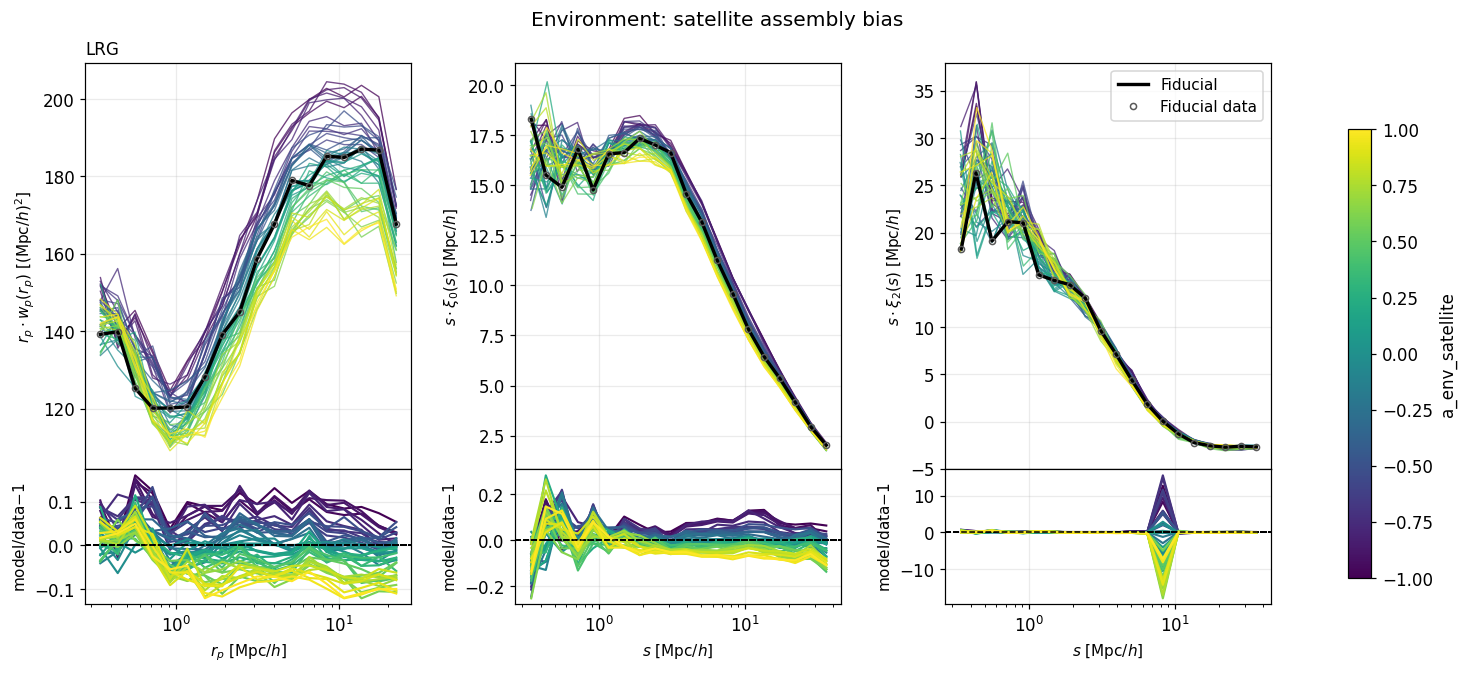

In [13]:
fig = plot_variation('a_env_satellite', PARAMETER_GRIDS["assembly_bias"], 'Environment: satellite assembly bias', proxy='env', component=1)
plt.close(fig)

## Satellite-count dispersion

`nu=1` is Poisson. The Conway–Maxwell–Poisson sampler uses `nu<1` for overdispersion and `nu>1` for underdispersion, with a mean-matching approximation. Both conformity and central-satellite linking are disabled here.

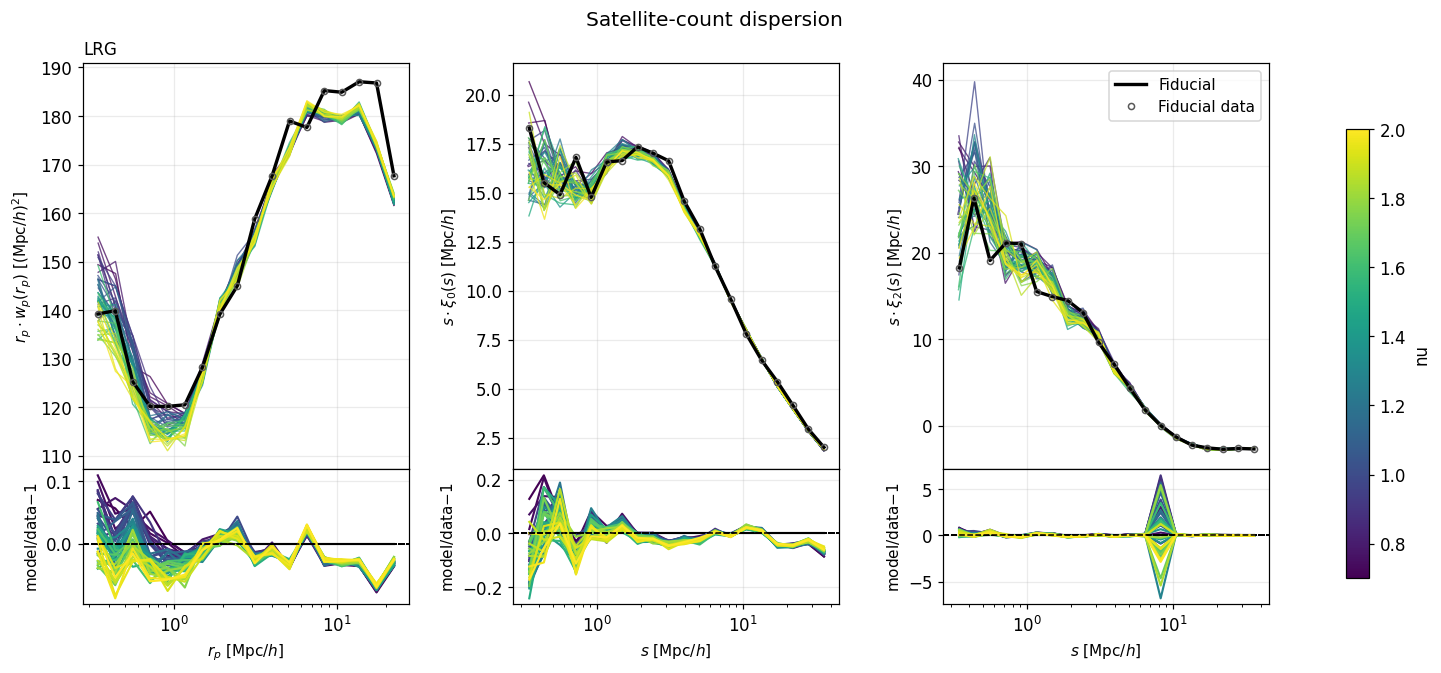

In [14]:
fig = plot_variation('nu', PARAMETER_GRIDS["nu"], 'Satellite-count dispersion')
plt.close(fig)

## Catalogue summary

The velocity-only runs should preserve occupation counts. Assembly-bias and dispersion runs can change the realized number density and satellite fraction, as reported below. The curves show one realization and a dense parameter grid per experiment; use multiple seeds and check mesh/particle-sampling convergence before interpreting small differences. To vary another coefficient, call `plot_variation` with a new parameter grid, keeping the fiducial configuration fixed.

In [15]:
print(f"{'Parameter':<28} {'Grid size':>9} {'N galaxies [min, max]':>24} {'f_sat [min, max]':>22}")
print(f"{'fiducial':<28} {1:>9} {str(run_summary[0]['N']):>24} {run_summary[0]['f_sat']:>22.3f}")
for parameter in dict.fromkeys(row["parameter"] for row in run_summary[1:]):
    rows = [row for row in run_summary if row["parameter"] == parameter]
    counts = [row["N"] for row in rows]
    fractions = [row["f_sat"] for row in rows]
    print(f"{parameter:<28} {len(rows):>9} "
          f"{f'{min(counts):,}, {max(counts):,}':>24} "
          f"{f'{min(fractions):.3f}, {max(fractions):.3f}':>22}")
# Individual values, counts and satellite fractions remain in run_summary.
assert hod.args["LRG"] == LRG_FIDUCIAL
expected = 1 + sum(len(PARAMETER_GRIDS[key]) for key in
                   ["f_sigv", "f_vcen", *(["assembly_bias"] * 6), "nu"])
assert len(run_summary) == expected
for row in (r for r in run_summary if r["parameter"] in ("f_sigv", "f_vcen")):
    assert row["N"] == run_summary[0]["N"]
    assert row["f_sat"] == run_summary[0]["f_sat"]


Parameter                    Grid size    N galaxies [min, max]       f_sat [min, max]
fiducial                             1                    61712                  0.136
f_sigv                              50           61,712, 61,712           0.136, 0.136
f_vcen                              50           61,712, 61,712           0.136, 0.136
assembly_bias.c.0                   50           61,671, 61,871           0.136, 0.137
assembly_bias.c.1                   50           61,638, 62,531           0.134, 0.139
assembly_bias.shear.0               50           61,691, 61,935           0.136, 0.137
assembly_bias.shear.1               50           61,649, 62,591           0.135, 0.140
assembly_bias.env.0                 50           61,669, 61,837           0.136, 0.137
assembly_bias.env.1                 50           61,625, 62,480           0.134, 0.139
nu                                  50           62,437, 62,489           0.137, 0.138
